In [1]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [8]:
filename = "data/preprocessed_combined_k_pxrf.xlsx" # removed an outlier row which had value 2861 for k


df = pd.read_excel(filename)
df.columns = df.columns.astype(str)
for i, col in enumerate(df.columns):
    print(i, col)
spectral_data = df.iloc[:, list(range(3,436))+[442]]
output_variable = df.iloc[:, 440:441]


0 uid
1 location
2 sample_id
3 349.866666666667
4 354.95
5 359.3
6 365.15
7 369.5
8 375.325
9 379.7
10 384.075
11 389.9
12 394.275
13 400.1
14 404.45
15 410.3
16 414.65
17 419
18 424.8
19 429.2
20 434.95
21 439.3
22 445.1
23 449.425
24 455.2
25 459.525
26 465.25
27 469.575
28 475.275
29 479.575
30 485.3
31 489.575
32 495.275
33 499.525
34 505.2
35 509.475
36 515.1
37 519.375
38 525
39 529.2
40 534.8
41 540.4
42 544.6
43 550.2
44 554.4
45 560
46 564.15
47 569.7
48 575.225
49 579.4
50 584.9
51 590.425
52 594.55
53 600.05
54 604.15
55 609.65
56 615.125
57 619.225
58 624.65
59 630.125
60 634.2
61 639.625
62 645.05
63 650.45
64 654.5
65 659.9
66 665.3
67 669.3
68 674.7
69 680.025
70 685.4
71 689.4
72 694.725
73 700.075
74 705.375
75 709.35
76 714.65
77 719.95
78 725.2
79 730.475
80 734.45
81 739.65
82 744.875
83 750.15
84 755.35
85 760.55
86 764.45
87 769.575
88 774.75
89 779.9
90 785.05
91 790.15
92 795.25
93 800.375
94 805.425
95 810.5
96 815.55
97 820.575
98 824.98
99 829.98
100 834.96
1

In [9]:
spectral_data.head()
output_variable.head()

,K
0,272
1,335
2,123
3,680
4,1173


In [10]:
print(spectral_data.shape)
print(output_variable.shape)

(149, 434)
(149, 1)


In [11]:
output_variable.describe()

,K
count,149.000000
mean,430.765101
std,259.740577
min,64.000000
25%,252.000000
50%,362.000000
75%,605.000000
max,1343.000000


Text(0.5, 1.0, 'Output K Distribution')

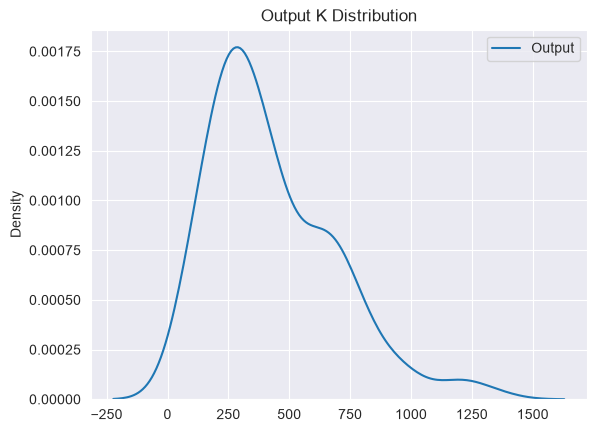

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output K Distribution")

In [13]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
#
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

In [14]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

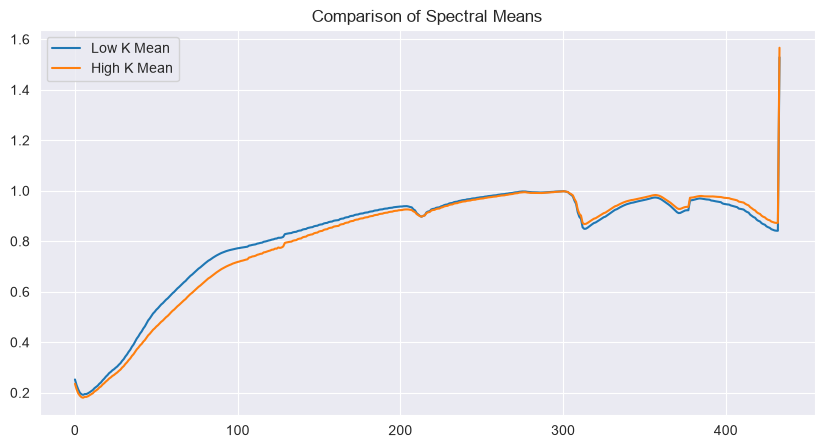

In [15]:

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low K Mean')
plt.plot(np.mean(high_n, axis=0), label='High K Mean')
plt.legend()
plt.title("Comparison of Spectral Means")
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)

#
pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [24]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [25]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.4442
LOOCV RMSE: 192.9951


Train/Test split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [27]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,2507.26666666667,K.1
22,0.207057,0.201176,0.181745,0.164542,0.168972,0.158532,0.164931,0.164309,0.165216,0.165786,...,0.882775,0.877075,0.875175,0.870615,0.863534,0.869130,0.854932,0.850925,0.860252,1.499867
15,0.361333,0.235588,0.205330,0.252762,0.213328,0.206740,0.236767,0.214160,0.221927,0.240118,...,0.924815,0.927958,0.922103,0.919514,0.914644,0.913165,0.914428,0.914428,0.911994,1.563233
65,0.294486,0.248949,0.232765,0.218048,0.205236,0.206664,0.211583,0.205514,0.215351,0.219119,...,0.772022,0.763083,0.757530,0.755785,0.747322,0.743462,0.739072,0.737697,0.737961,1.644300
11,0.311849,0.219691,0.209301,0.232581,0.195688,0.199022,0.216524,0.203912,0.209746,0.221830,...,0.873949,0.873393,0.867874,0.860651,0.861022,0.852021,0.859836,0.855873,0.854243,1.603567
42,0.223714,0.208908,0.189445,0.175717,0.172087,0.169890,0.174863,0.175320,0.178920,0.184015,...,0.924954,0.917714,0.917145,0.914013,0.911450,0.908969,0.906650,0.907749,0.907098,1.807800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.890058,1.664700
106,0.182750,0.164332,0.159684,0.145615,0.143632,0.143384,0.143694,0.144376,0.148280,0.149427,...,0.883752,0.873546,0.871522,0.869042,0.861068,0.858300,0.856069,0.853466,0.853176,1.554800
14,0.261431,0.194394,0.198842,0.190763,0.177894,0.190195,0.188448,0.183137,0.192329,0.193146,...,0.846664,0.843940,0.839128,0.837222,0.831835,0.824240,0.825329,0.825208,0.823695,1.420833
92,0.283301,0.251802,0.214142,0.216621,0.204456,0.194305,0.199496,0.202363,0.200814,0.208408,...,0.847423,0.841689,0.838176,0.834922,0.830686,0.830531,0.826450,0.821697,0.819682,1.583900


In [28]:

pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [32]:


# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', PLSRegression(n_components=2))
])

In [33]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

Best R2: 0.29103192417890356


In [34]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: -0.1253678332611512
RMSE: 192.9951


Feature selection using lasso

In [35]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.4)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


In [36]:
X_train_selected

array([[0.20705736, 0.20117623, 0.18174517, ..., 0.97973988, 0.92840734,
        1.49986667],
       [0.36133327, 0.23558781, 0.20533031, ..., 0.97988997, 0.95905568,
        1.56323333],
       [0.29448631, 0.24894883, 0.23276478, ..., 0.92820309, 0.81650139,
        1.6443    ],
       ...,
       [0.26143138, 0.19439401, 0.19884249, ..., 0.93735815, 0.89208655,
        1.42083333],
       [0.28330105, 0.25180163, 0.21414181, ..., 0.9614878 , 0.88126049,
        1.5839    ],
       [0.19403015, 0.18609987, 0.15439889, ..., 0.96970795, 0.90276352,
        1.5527    ]], shape=(119, 9))

In [37]:

pls = PLSRegression(n_components=7)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.1396137967001969
RMSE: 198.70965786005098


Feature Importance from RF

In [38]:

# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=6)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.531756670901786
RMSE: 146.59125271501384


In [39]:
X_train_selected_rf

array([[0.20705736, 0.20117623, 0.18174517, ..., 0.85092492, 0.86025183,
        1.49986667],
       [0.36133327, 0.23558781, 0.20533031, ..., 0.91442837, 0.91199359,
        1.56323333],
       [0.29448631, 0.24894883, 0.23276478, ..., 0.73769668, 0.73796113,
        1.6443    ],
       ...,
       [0.26143138, 0.19439401, 0.19884249, ..., 0.82520805, 0.82369496,
        1.42083333],
       [0.28330105, 0.25180163, 0.21414181, ..., 0.82169702, 0.81968229,
        1.5839    ],
       [0.19403015, 0.18609987, 0.15439889, ..., 0.83074694, 0.83557756,
        1.5527    ]], shape=(119, 217))

In [40]:
mask = selector_rf.get_support()

selected_columns = X_train.columns[mask]

# 3. View the results
print(f"Number of features selected: {len(selected_columns)}")
print("Selected columns (wavelengths):")
print(selected_columns)

Number of features selected: 217
Selected columns (wavelengths):
Index(['349.866666666667', '354.95', '359.3', '365.15', '369.5', '375.325',
       '384.075', '400.1', '424.8', '439.3',
       ...
       '2452.13333333333', '2460', '2467.13333333333', '2474.96666666667',
       '2479.2', '2489.8', '2494', '2504.5', '2507.26666666667', 'K.1'],
      dtype='str', length=217)


RF with GridSearchCV

In [41]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV RMSE: -0.17036410846500605


In [42]:
best_rf = grid.best_estimator_

In [43]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: 0.2670474085426531
Test MSE: 33637.24343166666
